# Project : Impact of Sample Processing (Fresh vs. Fixed vs. Fixed-Stored) on Single-Cell Transcriptomic Profiling of Diseased PBMCs in Primary Myelofibrosis

### Section 1: Import Library and Load Data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [14]:
!pip install 'scanpy[leiden]' "pandas < 3.0"

In [15]:
import scanpy as sc
import anndata as ad 

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
path = '/content/drive/MyDrive/PBMC/'

In [19]:
# Set path to your PBMC files in Google Drive
path = '/content/drive/MyDrive/PBMC/'  # ← Update this to your actual path

# Load all three datasets
adata_fresh = sc.read_10x_h5(path + '10k_3p_Human_diseased_PBMC_Myelofibrosis_Fresh_count_filtered_feature_bc_matrix.h5')
adata_fix = sc.read_10x_h5(path + '10k_3p_Human_diseased_PBMC_Myelofibrosis_Fix_count_filtered_feature_bc_matrix.h5')
adata_stored = sc.read_10x_h5(path + '10k_3p_Human_diseased_PBMC_Myelofibrosis_Fix_stored_count_filtered_feature_bc_matrix.h5')

# Fix duplicate gene names immediately
adata_fresh.var_names_make_unique()
adata_fix.var_names_make_unique()
adata_stored.var_names_make_unique()

print("Loaded successfully")
print(f"  Fresh:        {adata_fresh.shape}")
print(f"  Fixed:        {adata_fix.shape}")
print(f"  Fixed_Stored: {adata_stored.shape}")


TypeError: StringDtype.__init__() got an unexpected keyword argument 'na_value'

In [ ]:
# Label each dataset with its condition
adata_fresh.obs['condition'] = 'Fresh'
adata_fix.obs['condition'] = 'Fixed'
adata_stored.obs['condition'] = 'Fixed_Stored'

NameError: name 'adata_fresh' is not defined

In [ ]:
# Shape check
print("=== Dataset Shapes ===")
print(f"Fresh:        {adata_fresh.shape[0]:,} cells × {adata_fresh.shape[1]:,} genes")
print(f"Fixed:        {adata_fix.shape[0]:,} cells × {adata_fix.shape[1]:,} genes")
print(f"Fixed_Stored: {adata_stored.shape[0]:,} cells × {adata_stored.shape[1]:,} genes")

# Gene names match?
print(f"\nGenes match (Fresh vs Fixed): {(adata_fresh.var_names == adata_fix.var_names).all()}")
print(f"Genes match (Fresh vs Stored): {(adata_fresh.var_names == adata_stored.var_names).all()}")

# Preview obs
print("\n=== .obs columns ===")
print(list(adata_fresh.obs.columns))
display(adata_fresh.obs.head(3))

# Preview var
print("\n=== .var (first 5 genes) ===")
display(adata_fresh.var.head())


=== Dataset Shapes ===
Fresh:        12,516 cells × 38,606 genes
Fixed:        11,538 cells × 38,606 genes
Fixed_Stored: 5,825 cells × 38,606 genes

Genes match (Fresh vs Fixed): True
Genes match (Fresh vs Stored): True

=== .obs columns ===
['condition']


,condition
AAACCAAAGGAATGGT-1,Fresh
AAACCAAAGGGCAGGT-1,Fresh
AAACCAAAGGTTGCCG-1,Fresh



=== .var (first 5 genes) ===


,gene_ids,feature_types,genome
DDX11L2,ENSG00000290825,Gene Expression,GRCh38
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38
FAM138A,ENSG00000237613,Gene Expression,GRCh38
ENSG00000290826,ENSG00000290826,Gene Expression,GRCh38
OR4F5,ENSG00000186092,Gene Expression,GRCh38


In [ ]:
# Make all names unique before merging
adata_fresh.obs_names_make_unique()
adata_fix.obs_names_make_unique()
adata_stored.obs_names_make_unique()

# Concatenate
adata = ad.concat(
    [adata_fresh, adata_fix, adata_stored],
    label='condition',
    keys=['Fresh', 'Fixed', 'Fixed_Stored'],
    join='inner',
    index_unique='-'
)

print(f"✅ Merged: {adata.shape[0]:,} cells × {adata.shape[1]:,} genes")
print(f"\nCells per condition:")
print(adata.obs['condition'].value_counts())


✅ Merged: 29,879 cells × 38,606 genes

Cells per condition:
condition
Fresh           12516
Fixed           11538
Fixed_Stored     5825
Name: count, dtype: int64


### Section 2: Quality Control

In [ ]:
# Mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-') 
# Ribosomal genes
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))

#  QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)

# Display the first few rows of the obs dataframe to see the new metrics
adata.obs.head()

,condition,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
AAACCAAAGGAATGGT-1-Fresh,Fresh,2592,8266.0,254.0,3.072829,2604.0,31.502542
AAACCAAAGGGCAGGT-1-Fresh,Fresh,1843,5050.0,120.0,2.376238,23.0,0.455446
AAACCAAAGGTTGCCG-1-Fresh,Fresh,4741,19662.0,456.0,2.319194,2691.0,13.686297
AAACCAAAGTCAGTGC-1-Fresh,Fresh,5256,24149.0,667.0,2.762019,3038.0,12.580231
AAACCATTCACAGATT-1-Fresh,Fresh,3058,11456.0,429.0,3.744762,3422.0,29.870811


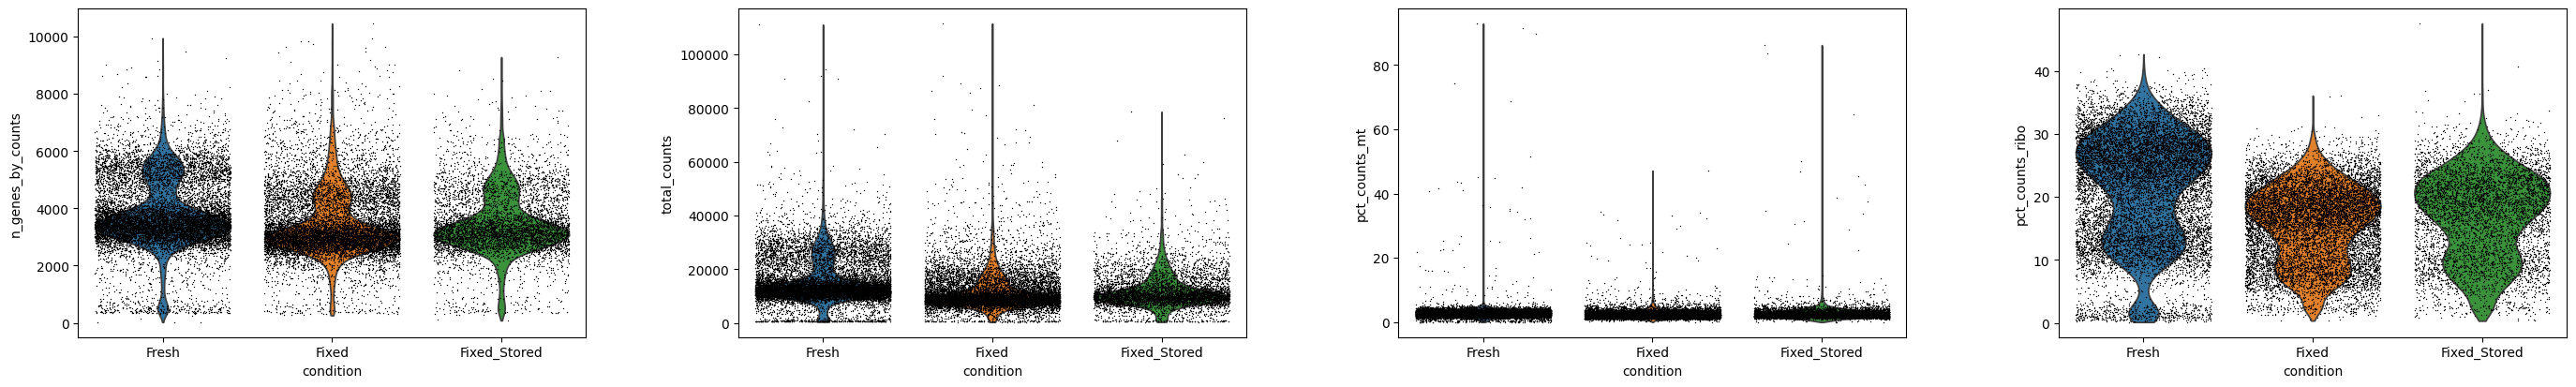

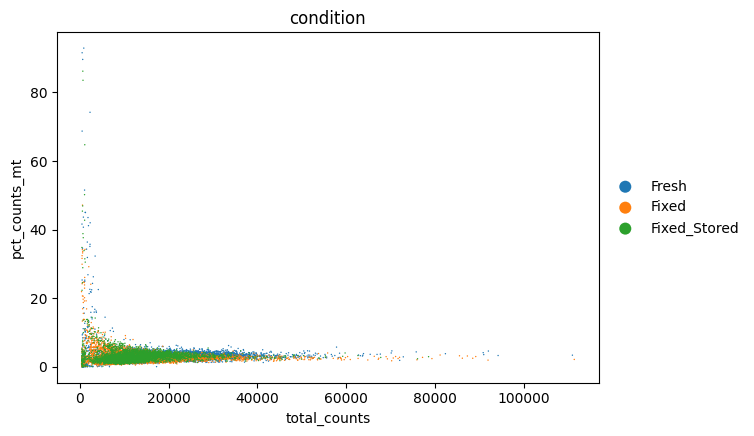

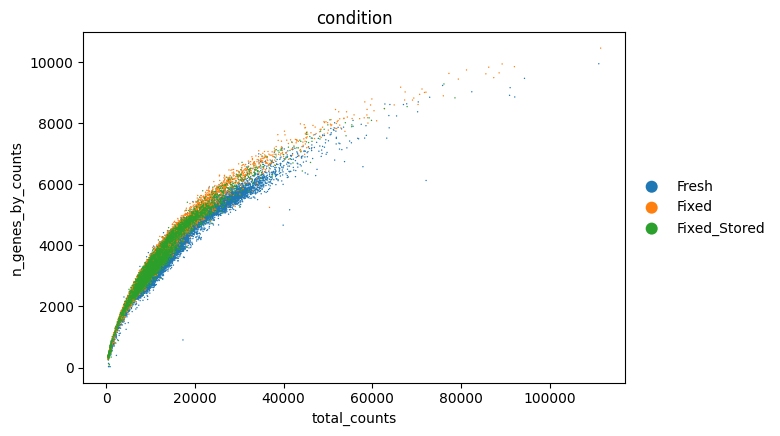

In [ ]:
# Violin plots of QC metrics, grouped by condition
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'],
             jitter=0.4, multi_panel=True, groupby='condition')

# Scatter plots to see the relationship between total counts, genes, and mt percentage
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', color='condition')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='condition')


### Section 3: Filtering

In [ ]:
# Basic filtering (Adjust these thresholds based on the plots above!)
print(f"Before filtering: {adata.n_obs} cells, {adata.n_vars} genes")

sc.pp.filter_cells(adata, min_genes=200)

adata = adata[adata.obs.n_genes_by_counts < 4000, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

sc.pp.filter_genes(adata, min_cells=3)

print(f"After filtering: {adata.n_obs} cells, {adata.n_vars} genes")

### Section 4: Normalization and Log Transformation

In [ ]:
# Normalize library size to 10,000 counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform the data
sc.pp.log1p(adata)

# Save the normalized and log-transformed data in .raw attribute for downstream differential expression
adata.raw = adata

print("Normalized and Log Transformed")

### Section 5: Feature Selection (Highly Variable Genes)

In [ ]:
# Identify highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pl.highly_variable_genes(adata)

# Filter the AnnData object to only keep highly variable genes
adata = adata[:, adata.var.highly_variable]
print(f"Number of highly variable genes: {adata.shape[1]}")

### Section 6: Scaling and Dimensionality Reduction (PCA)

In [ ]:
# Scale the data (set mean to 0 and variance to 1, clip extreme values)
sc.pp.scale(adata, max_value=10)

# Run PCA
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)

In [ ]:
# Plot PCA colored by sample condition
sc.pl.pca(adata, color='condition')

### Section 7: Dimensionality Reduction (UMAP)

In [ ]:
# Compute the neighborhood graph (use 15 PCs as a starting point based on the variance ratio elbow plot)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=15)

# Run UMAP
sc.tl.umap(adata)

# Plot UMAP colored by condition
sc.pl.umap(adata, color='condition')

### Section 8: Clustering

In [ ]:
# Run Leiden clustering (resolution 0.5 is typical for finding main PBMC cell types)
sc.tl.leiden(adata, resolution=0.5, key_added='leiden')

# Plot UMAP showing clusters alongside conditions
sc.pl.umap(adata, color=['leiden', 'condition'], legend_loc='on data')

### Section 9: Cell Type Annotation

In [ ]:
# 1. Find marker genes for each cluster using Wilcoxon rank-sum test
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

# 2. Show the top 10 ranked genes for each cluster as a dataframe
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(10)

In [ ]:
# 3. Plot classic PBMC marker genes to help identify clusters
marker_genes = {
    'T-cells': ['CD3D', 'CD3E', 'CD4', 'CD8A'],
    'NK-cells': ['GNLY', 'NKG7'],
    'B-cells': ['MS4A1', 'CD79A'],
    'Monocytes': ['CD14', 'LYZ', 'FCGR3A', 'MS4A7'],
    'Dendritic': ['FCER1A', 'CST3'],
    'Megakaryocytes': ['PPBP']
}

# Filter marker genes list to only include genes present in the data's raw expression matrix
markers_in_raw = {k: [g for g in v if g in adata.raw.var_names] for k, v in marker_genes.items()}

# Plot expression of marker genes in each cluster
sc.pl.dotplot(adata, markers_in_raw, groupby='leiden', use_raw=True)

In [ ]:
# 4. Annotation mapping placeholder (Update this dictionary after inspecting marker genes!)
cell_type_map = {
    '0': 'T Cells (CD4+)',
    '1': 'B Cells',
    '2': 'Monocytes (CD14+)',
    '3': 'T Cells (CD8+)',
    '4': 'NK Cells',
    '5': 'Monocytes (FCGR3A+)',
    '6': 'Dendritic Cells',
    '7': 'Platelets/Megakaryocytes'
}

# Map clusters to cell types
# adata.obs['cell_type'] = adata.obs['leiden'].map(cell_type_map)
# sc.pl.umap(adata, color='cell_type')

### Section 10: Differential Expression Analysis (Condition vs. Condition)

In [ ]:
# Compare Fixed and Fixed_Stored conditions against the Fresh control group
sc.tl.rank_genes_groups(adata, groupby='condition', reference='Fresh', method='wilcoxon')

# Plot the top differentially expressed genes between conditions
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

In [ ]:
# Plot a heatmap of the top 10 differentially expressed genes for each condition
sc.pl.rank_genes_groups_heatmap(adata, n_genes=10, groupby='condition', use_raw=True, show_gene_labels=True, cmap='bwr')